In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("novatel-customer-intelligence/train.csv")

In [3]:
train.head()

,customer_id,age,tenure_months,number_of_services,data_usage_gb,streaming_hours_monthly,device_age_months,app_sessions_weekly,average_session_minutes,payment_delay_days,late_payment_count,discount_percentage,monthly_charge,network_complaints,support_calls_90d,satisfaction_score,referral_count,lifetime_spend,customer_segment,region,acquisition_channel,contract_type,plan_tier,internet_type,device_type,support_plan,payment_method,promotion_type,streaming_service,priority_support,autopay,paperless_billing,family_plan,international_plan,churn
0,NVT-LGAUGXNSBQFF,50.0,59.0,5.0,5.91,0.0,55.0,14.0,10.4,0.0,NaN,23.0,51.75,0.0,1.0,9.1,0.0,2283.57,Consumer,Northgate,Outbound sales,Two year,NovaStart,Fiber,NaN,NovaCare Basic,Credit card (autopay),Loyalty credit,0.0,0.0,1.0,1.0,1.0,0.0,0
1,NVT-KK5E9TRTJYUG,28.0,29.0,4.0,3.03,NaN,3.0,10.0,4.9,0.0,0.0,0.0,63.88,0.0,27.0,6.4,0.0,1422.24,Enterprise,NaN,Referral,Two year,NovaMax,Cable/DSL,Android,NovaCare Premium,Credit card (autopay),No Promotion,0.0,1.0,NaN,1.0,0.0,1.0,0
2,NVT-WC2AWMHHLTTM,59.0,14.0,7.0,86.69,0.0,10.0,10.0,8.1,0.0,0.0,0.0,89.40,2.0,1.0,NaN,0.0,930.22,Enterprise,Northgate,Retail store,Two year,NovaMax,Fiber,Android,NovaCare Premium,Bank transfer (autopay),No Promotion,0.0,1.0,1.0,NaN,0.0,1.0,0
3,NVT-WN5PLHPLH7T4,41.0,9.0,1.0,96.32,3.5,2.0,NaN,21.9,0.0,0.0,3.0,52.92,1.0,2.0,7.7,0.0,570.98,Consumer,Westhaven,Outbound sales,Month-to-month,NovaMax,5G Fixed Wireless,Android,No Plan,Bank transfer (autopay),Free month,1.0,0.0,1.0,0.0,0.0,0.0,1
4,NVT-U2ZXSGY3KM9C,55.0,38.0,NaN,3.38,0.0,9.0,11.0,NaN,0.0,0.0,2.0,46.53,1.0,2.0,8.5,0.0,1555.89,Small Business,Northgate,Partner reseller,Two year,NovaStart,Fiber,Android,NaN,Bank transfer (autopay),NaN,0.0,0.0,NaN,1.0,0.0,0.0,0


### tenure_bin

In [4]:
train['tenure_months']

0        59.0
1        29.0
2        14.0
3         9.0
4        38.0
         ... 
11995    13.0
11996     9.0
11997    67.0
11998    22.0
11999     1.0
Name: tenure_months, Length: 12000, dtype: float64

In [5]:
def create_tenure_bins(
    train_df,
    column="tenure_months",
    n_bins=10
):
    """
    Create leakage-safe quantile-based bins for a numeric feature.

    Bin boundaries are learned only from the training dataset.
    The same boundaries are then applied to validation and test data.
    """

    train_df = train_df.copy()

    # Learn bin boundaries ONLY from training data
    _, bin_edges = pd.qcut(
        train_df[column],
        q=n_bins,
        retbins=True,
        duplicates="drop"
    )

    # Extend boundaries to handle future unseen values
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    train_df[f"{column}_bin"] = pd.cut(
        train_df[column],
        bins=bin_edges,
        labels=False,
        include_lowest=True
    )

    return train_df, bin_edges

train, tenure_edges = create_tenure_bins(
    train,
    column="tenure_months",
    n_bins=10
)

print("Learned bin edges:")
print(tenure_edges)

Learned bin edges:
[-inf   3.   6.   9.  12.  15.  20.  24.  31.  43.  inf]


In [6]:
from sklearn.tree import DecisionTreeClassifier


def learn_optimal_bins(
    train_df,
    column,
    target,
    max_bins=6,
    min_samples_leaf=0.05
):
    """
    Learn fraud-aware bins for a numeric feature using only training data.
    """

    X = train_df[[column]]
    y = train_df[target]

    tree = DecisionTreeClassifier(
        max_leaf_nodes=max_bins,
        min_samples_leaf=min_samples_leaf,
        criterion="entropy",
        random_state=42
    )

    tree.fit(X, y)

    thresholds = tree.tree_.threshold

    thresholds = sorted(
        threshold
        for threshold in thresholds
        if threshold != -2
    )

    return thresholds

thresholds = learn_optimal_bins(
    train_df=train,
    column="tenure_months",
    target="churn",
    max_bins=6
)

print("Learned thresholds:")
print(thresholds)

Learned thresholds:
[np.float64(2.5), np.float64(7.5), np.float64(11.5), np.float64(23.5), np.float64(38.5)]


In [7]:
thresholds = [2.5, 7.5, 11.5, 23.5, 38.5]
bins = [-np.inf] + thresholds + [np.inf]

train["tenure_bin"] = pd.cut(
    train["tenure_months"],
    bins=bins,
    labels=False,
    include_lowest=True
)

   tenure_bin  transactions  churn  churn_rate
0         0.0           827    401    0.484885
1         1.0          2047    766    0.374206
2         2.0          1519    402    0.264648
3         3.0          3510    742    0.211396
4         4.0          2104    361    0.171578
5         5.0          1513    166    0.109716


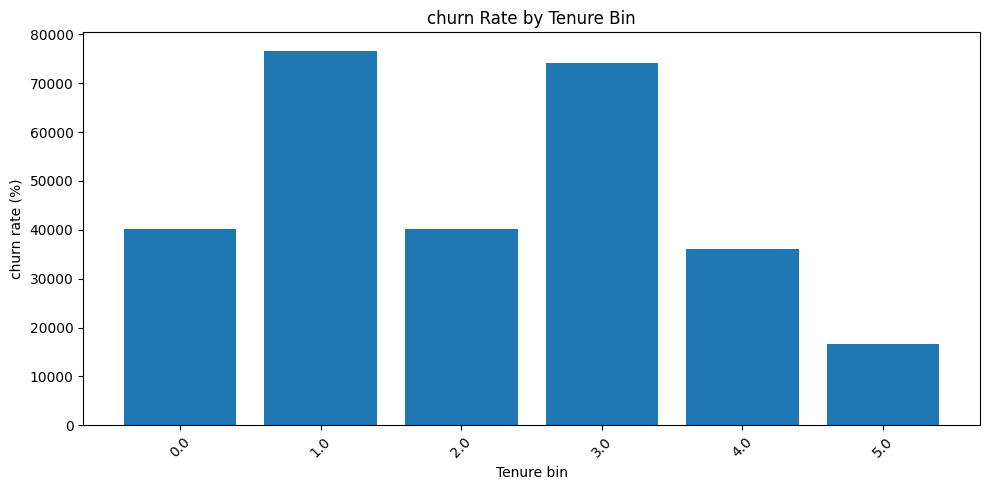

In [8]:
tenure_analysis = (
    train
    .groupby("tenure_bin", observed=True)
    .agg(
        transactions=("churn", "size"),
        churn=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(tenure_analysis)

plt.figure(figsize=(10, 5))

plt.bar(
    tenure_analysis["tenure_bin"].astype(str),
    tenure_analysis["churn"] * 100
)

plt.xlabel("Tenure bin")
plt.ylabel("churn rate (%)")
plt.title("churn Rate by Tenure Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
train['tenure_bin'].value_counts()

tenure_bin
3.0    3510
4.0    2104
1.0    2047
2.0    1519
5.0    1513
0.0     827
Name: count, dtype: int64

### satisfaction_bin

In [10]:
train['satisfaction_score']

0         9.1
1         6.4
2         NaN
3         7.7
4         8.5
         ... 
11995     9.1
11996     6.9
11997    10.0
11998     7.9
11999     8.3
Name: satisfaction_score, Length: 12000, dtype: float64

In [11]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="satisfaction_score",
    target="churn",
    max_bins=6
)
print("Learned thresholds:")
print(thresholds)

Learned thresholds:
[np.float64(6.25), np.float64(6.950000047683716), np.float64(7.549999952316284), np.float64(8.150000095367432), np.float64(9.050000190734863)]


In [12]:
thresholds = [6.25, 6.950000047683716, 7.549999952316284, 8.150000095367432, 9.050000190734863]
bins = [-np.inf] + thresholds + [np.inf]

train["satisfaction_bin"] = pd.cut(
    train["satisfaction_score"],
    bins=bins,
    labels=False,
    include_lowest=True
)

   satisfaction_bin  transactions  churn  churn_rate
0               0.0           847    438    0.517119
1               1.0          1258    494    0.392687
2               2.0          1790    519    0.289944
3               3.0          2122    500    0.235627
4               4.0          2982    559    0.187458
5               5.0          2327    258    0.110872


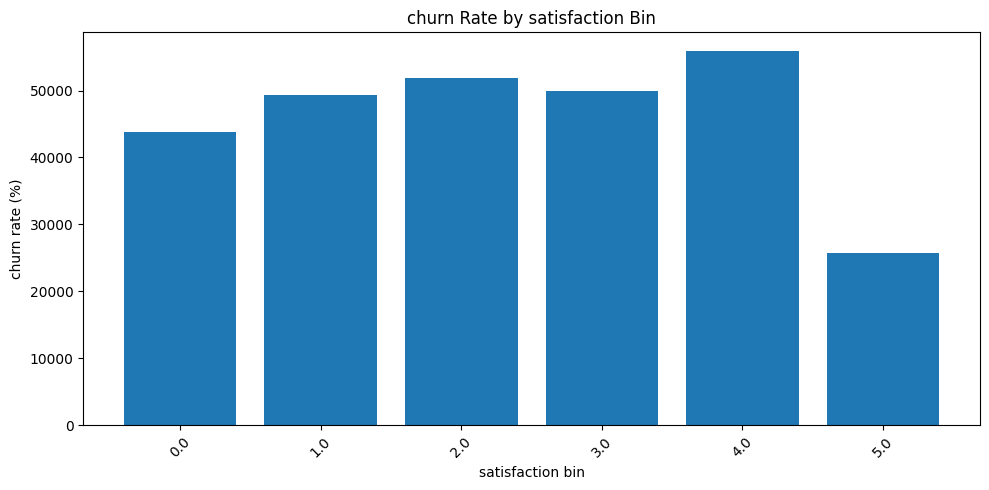

In [13]:
satisfaction_analysis = (
    train
    .groupby("satisfaction_bin", observed=True)
    .agg(
        transactions=("churn", "size"),
        churn=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(satisfaction_analysis)

plt.figure(figsize=(10, 5))

plt.bar(
    satisfaction_analysis["satisfaction_bin"].astype(str),
    satisfaction_analysis["churn"] * 100
)

plt.xlabel("satisfaction bin")
plt.ylabel("churn rate (%)")
plt.title("churn Rate by satisfaction Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### monthly_charge

In [14]:
train['monthly_charge']

0        51.75
1        63.88
2        89.40
3        52.92
4        46.53
         ...  
11995    49.38
11996    69.37
11997    24.35
11998    54.30
11999    48.80
Name: monthly_charge, Length: 12000, dtype: float64

In [15]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="monthly_charge",
    target="churn",
    max_bins=6
)
print("Learned thresholds:")
print(thresholds)

Learned thresholds:
[np.float64(38.625), np.float64(40.704999923706055), np.float64(43.44499969482422), np.float64(58.23500061035156), np.float64(68.60499954223633)]


In [16]:
thresholds = [38.625, 40.704999923706055, 43.44499969482422, 58.23500061035156, 68.60499954223633]
bins = [-np.inf] + thresholds + [np.inf]

train["monthly_charge_bin"] = pd.cut(
    train["monthly_charge"],
    bins=bins,
    labels=False,
    include_lowest=True
)

   monthly_charge_bin  transactions  churn  churn_rate
0                 0.0          3312    694    0.209541
1                 1.0           612    158    0.258170
2                 2.0           875    152    0.173714
3                 3.0          4426   1064    0.240398
4                 4.0          1564    570    0.364450
5                 5.0           759    199    0.262187


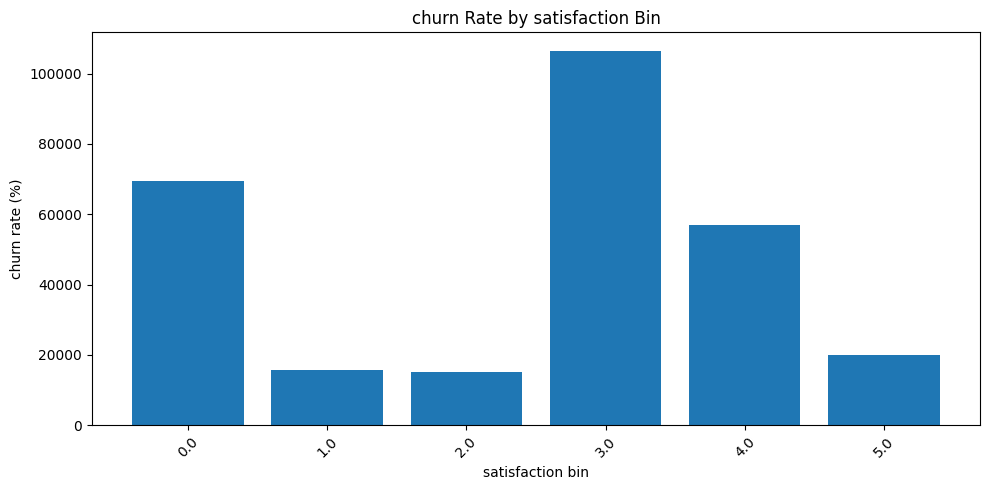

In [17]:
monthly_charge_bin_analysis = (
    train
    .groupby("monthly_charge_bin", observed=True)
    .agg(
        transactions=("churn", "size"),
        churn=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(monthly_charge_bin_analysis)

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_charge_bin_analysis["monthly_charge_bin"].astype(str),
    monthly_charge_bin_analysis["churn"] * 100
)

plt.xlabel("satisfaction bin")
plt.ylabel("churn rate (%)")
plt.title("churn Rate by satisfaction Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
train.columns

Index(['customer_id', 'age', 'tenure_months', 'number_of_services',
       'data_usage_gb', 'streaming_hours_monthly', 'device_age_months',
       'app_sessions_weekly', 'average_session_minutes', 'payment_delay_days',
       'late_payment_count', 'discount_percentage', 'monthly_charge',
       'network_complaints', 'support_calls_90d', 'satisfaction_score',
       'referral_count', 'lifetime_spend', 'customer_segment', 'region',
       'acquisition_channel', 'contract_type', 'plan_tier', 'internet_type',
       'device_type', 'support_plan', 'payment_method', 'promotion_type',
       'streaming_service', 'priority_support', 'autopay', 'paperless_billing',
       'family_plan', 'international_plan', 'churn', 'tenure_months_bin',
       'tenure_bin', 'satisfaction_bin', 'monthly_charge_bin'],
      dtype='object')

### age

In [19]:
train['age']

0        50.0
1        28.0
2        59.0
3        41.0
4        55.0
         ... 
11995    45.0
11996    40.0
11997    32.0
11998    63.0
11999    41.0
Name: age, Length: 12000, dtype: float64

In [20]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="age",
    target="churn",
    max_bins=4
)
print("Learned thresholds:")
print(thresholds)

Learned thresholds:
[np.float64(19.5), np.float64(29.5), np.float64(64.5)]


In [21]:
# thresholds = [19.5, 22.5, 25.5, 29.5, 64.5]
bins = [-np.inf] + thresholds + [np.inf]

train["age_bin"] = pd.cut(
    train["age"],
    bins=bins,
    labels=False,
    include_lowest=True
)

   age_bin  transactions  churn  churn_rate
0      0.0           663    207    0.312217
1      1.0          2210    815    0.368778
2      2.0          7826   1594    0.203680
3      3.0           929    250    0.269107


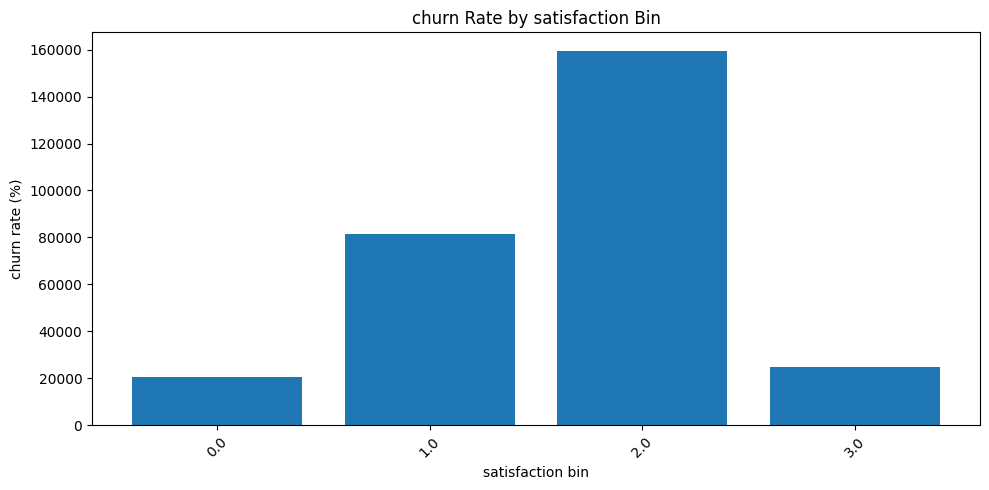

In [22]:
age_bin_analysis = (
    train
    .groupby("age_bin", observed=True)
    .agg(
        transactions=("churn", "size"),
        churn=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(age_bin_analysis)

plt.figure(figsize=(10, 5))

plt.bar(
    age_bin_analysis["age_bin"].astype(str),
    age_bin_analysis["churn"] * 100
)

plt.xlabel("satisfaction bin")
plt.ylabel("churn rate (%)")
plt.title("churn Rate by satisfaction Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
columns = ["customer_id","age","tenure_months","monthly_charge","tenure_months_bin","satisfaction_score"]

In [24]:
train.head()

,customer_id,age,tenure_months,number_of_services,data_usage_gb,streaming_hours_monthly,device_age_months,app_sessions_weekly,average_session_minutes,payment_delay_days,late_payment_count,discount_percentage,monthly_charge,network_complaints,support_calls_90d,satisfaction_score,referral_count,lifetime_spend,customer_segment,region,acquisition_channel,contract_type,plan_tier,internet_type,device_type,support_plan,payment_method,promotion_type,streaming_service,priority_support,autopay,paperless_billing,family_plan,international_plan,churn,tenure_months_bin,tenure_bin,satisfaction_bin,monthly_charge_bin,age_bin
0,NVT-LGAUGXNSBQFF,50.0,59.0,5.0,5.91,0.0,55.0,14.0,10.4,0.0,NaN,23.0,51.75,0.0,1.0,9.1,0.0,2283.57,Consumer,Northgate,Outbound sales,Two year,NovaStart,Fiber,NaN,NovaCare Basic,Credit card (autopay),Loyalty credit,0.0,0.0,1.0,1.0,1.0,0.0,0,9.0,5.0,5.0,3.0,2.0
1,NVT-KK5E9TRTJYUG,28.0,29.0,4.0,3.03,NaN,3.0,10.0,4.9,0.0,0.0,0.0,63.88,0.0,27.0,6.4,0.0,1422.24,Enterprise,NaN,Referral,Two year,NovaMax,Cable/DSL,Android,NovaCare Premium,Credit card (autopay),No Promotion,0.0,1.0,NaN,1.0,0.0,1.0,0,7.0,4.0,1.0,4.0,1.0
2,NVT-WC2AWMHHLTTM,59.0,14.0,7.0,86.69,0.0,10.0,10.0,8.1,0.0,0.0,0.0,89.40,2.0,1.0,NaN,0.0,930.22,Enterprise,Northgate,Retail store,Two year,NovaMax,Fiber,Android,NovaCare Premium,Bank transfer (autopay),No Promotion,0.0,1.0,1.0,NaN,0.0,1.0,0,4.0,3.0,NaN,5.0,2.0
3,NVT-WN5PLHPLH7T4,41.0,9.0,1.0,96.32,3.5,2.0,NaN,21.9,0.0,0.0,3.0,52.92,1.0,2.0,7.7,0.0,570.98,Consumer,Westhaven,Outbound sales,Month-to-month,NovaMax,5G Fixed Wireless,Android,No Plan,Bank transfer (autopay),Free month,1.0,0.0,1.0,0.0,0.0,0.0,1,2.0,2.0,3.0,3.0,2.0
4,NVT-U2ZXSGY3KM9C,55.0,38.0,NaN,3.38,0.0,9.0,11.0,NaN,0.0,0.0,2.0,46.53,1.0,2.0,8.5,0.0,1555.89,Small Business,Northgate,Partner reseller,Two year,NovaStart,Fiber,Android,NaN,Bank transfer (autopay),NaN,0.0,0.0,NaN,1.0,0.0,0.0,0,8.0,4.0,4.0,3.0,2.0


In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              12000 non-null  object 
 1   age                      11628 non-null  float64
 2   tenure_months            11520 non-null  float64
 3   number_of_services       11584 non-null  float64
 4   data_usage_gb            11493 non-null  float64
 5   streaming_hours_monthly  11192 non-null  float64
 6   device_age_months        11664 non-null  float64
 7   app_sessions_weekly      11498 non-null  float64
 8   average_session_minutes  11425 non-null  float64
 9   payment_delay_days       11346 non-null  float64
 10  late_payment_count       11420 non-null  float64
 11  discount_percentage      11374 non-null  float64
 12  monthly_charge           11548 non-null  float64
 13  network_complaints       11373 non-null  float64
 14  support_calls_90d     

### number_of_services

In [26]:
train['number_of_services'].value_counts()

number_of_services
1.0    3352
2.0    2929
3.0    2371
4.0    1581
5.0     793
6.0     368
7.0     190
Name: count, dtype: int64

<Axes: xlabel='number_of_services', ylabel='churn'>

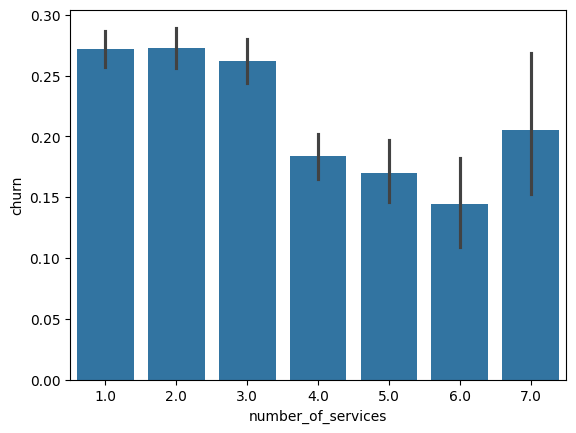

In [27]:
sns.barplot(data=train,x=train['number_of_services'],y=train['churn'])

In [28]:
service_analysis = (
    train
    .groupby("number_of_services", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(service_analysis)

   number_of_services  customers  churned  churn_rate
0                 1.0       3352      912    0.272076
1                 2.0       2929      799    0.272789
2                 3.0       2371      622    0.262337
3                 4.0       1581      291    0.184061
4                 5.0        793      135    0.170240
5                 6.0        368       53    0.144022
6                 7.0        190       39    0.205263


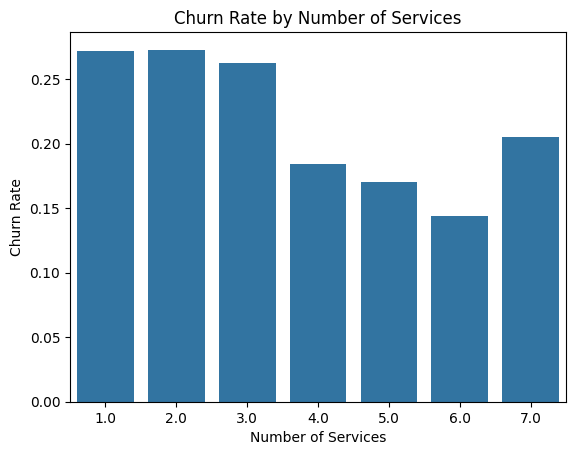

In [29]:
sns.barplot(
    data=service_analysis,
    x="number_of_services",
    y="churn_rate"
)

plt.ylabel("Churn Rate")
plt.xlabel("Number of Services")
plt.title("Churn Rate by Number of Services")
plt.show()

### data_usage_gb

In [30]:
train['data_usage_gb'].value_counts()

data_usage_gb
0.24      15
0.38      14
0.41      14
7.25      14
4.52      13
          ..
33.26      1
103.35     1
20.65      1
39.05      1
15.57      1
Name: count, Length: 4315, dtype: int64

In [31]:
print(train["data_usage_gb"].describe())

print(train["data_usage_gb"].nunique())

print(train["data_usage_gb"].value_counts().head(20))

count    11493.000000
mean        19.028579
std         24.236379
min          0.030000
25%          5.810000
50%         11.840000
75%         23.030000
max        505.700000
Name: data_usage_gb, dtype: float64
4315
data_usage_gb
0.24     15
0.38     14
0.41     14
7.25     14
4.52     13
2.87     13
0.18     12
6.04     12
5.64     12
0.19     12
0.28     11
9.02     11
0.26     11
0.69     11
4.17     11
6.84     11
3.57     11
9.66     11
9.60     11
11.01    10
Name: count, dtype: int64


In [32]:
train['data_usage_gb'].value_counts(bins=3)

(-0.477, 168.587]     11458
(168.587, 337.143]       32
(337.143, 505.7]          3
Name: count, dtype: int64

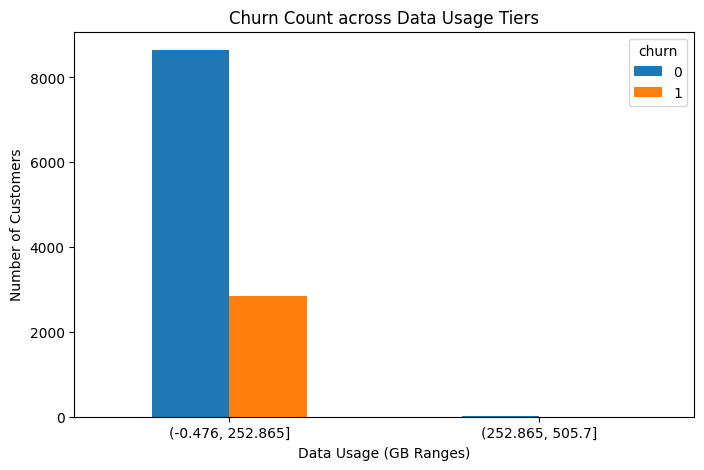

In [33]:
# 1. Create a binned column with 3 equal intervals

train['usage_bins'] = pd.cut(train['data_usage_gb'], bins=2)

# 2. Create a crosstab between usage bins and churn
churn_by_bin = pd.crosstab(train['usage_bins'], train['churn'])

# 3. Plot a side-by-side bar chart
churn_by_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

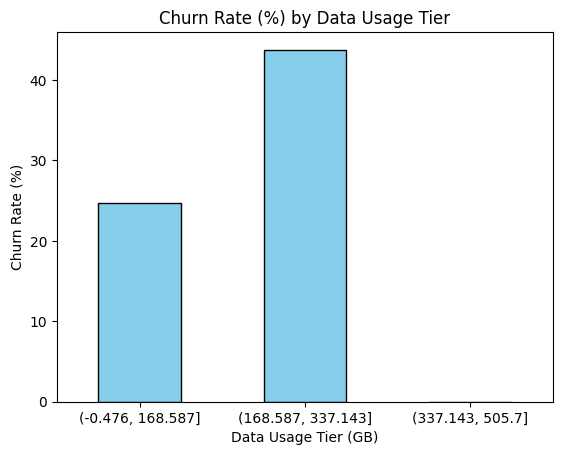

In [34]:
# Create 3 usage bins
train['usage_bins'] = pd.cut(train['data_usage_gb'], bins=3)

# Calculate average churn rate per bin (assuming churn is 1 for Churned, 0 for Retained)
churn_rate = train.groupby('usage_bins')['churn'].mean() * 100

# Plot Churn Rate (%)
churn_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Churn Rate (%) by Data Usage Tier')
plt.xlabel('Data Usage Tier (GB)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [35]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="data_usage_gb",
    target="churn",
    max_bins=6
)

print(thresholds)

[np.float64(7.224999904632568), np.float64(8.414999961853027), np.float64(15.545000076293945), np.float64(21.914999961853027), np.float64(34.7450008392334)]


In [36]:
bins = [-np.inf] + thresholds + [np.inf]

train["data_usage_bin"] = pd.cut(
    train["data_usage_gb"],
    bins=bins,
    labels=False,
    include_lowest=True
)

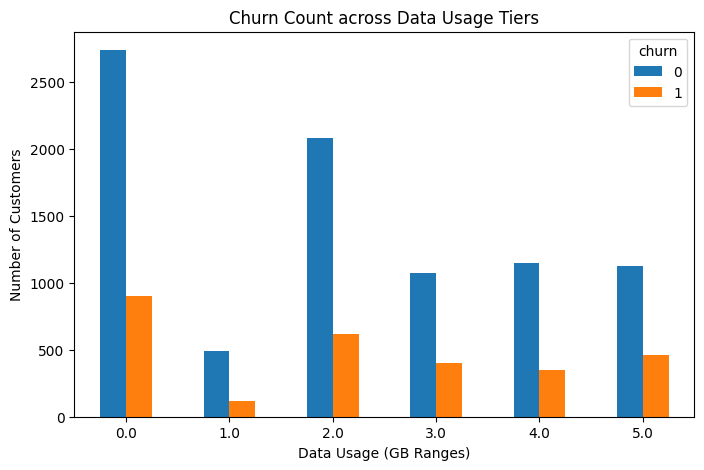

In [37]:
# 2. Create a crosstab between usage bins and churn
churn_by_bin = pd.crosstab(train['data_usage_bin'], train['churn'])

# 3. Plot a side-by-side bar chart
churn_by_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### streaming_hours_monthly

In [38]:
print(train["streaming_hours_monthly"].describe())
print("Unique values:", train["streaming_hours_monthly"].nunique())
print(train["streaming_hours_monthly"].value_counts().head(20))

count    11192.000000
mean         9.627627
std         16.661163
min          0.000000
25%          0.000000
50%          2.100000
75%         13.900000
max        327.700000
Name: streaming_hours_monthly, dtype: float64
Unique values: 690
streaming_hours_monthly
0.0     5539
8.8       40
6.5       37
8.9       36
7.7       35
10.3      34
7.1       34
4.9       33
6.6       33
7.3       32
5.8       32
8.3       31
9.3       31
5.7       31
8.2       31
7.2       31
11.0      31
7.4       30
7.6       30
5.3       30
Name: count, dtype: int64


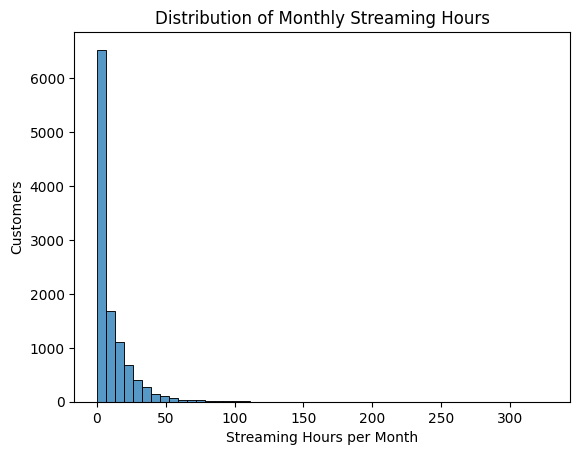

In [39]:
sns.histplot(
    data=train,
    x="streaming_hours_monthly",
    bins=50
)

plt.xlabel("Streaming Hours per Month")
plt.ylabel("Customers")
plt.title("Distribution of Monthly Streaming Hours")
plt.show()

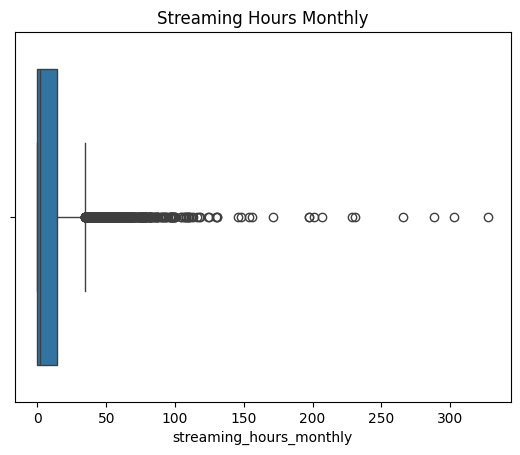

In [40]:
sns.boxplot(
    data=train,
    x="streaming_hours_monthly"
)

plt.title("Streaming Hours Monthly")
plt.show()

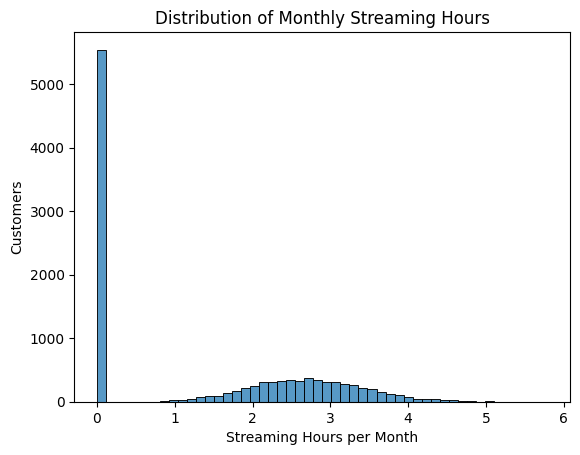

In [41]:
# train["streaming_hours_log"] = np.log1p(train["streaming_hours_monthly"])

sns.histplot(
    data=train,
    x=np.log1p(train["streaming_hours_monthly"]),
    bins=50
)

plt.xlabel("Streaming Hours per Month")
plt.ylabel("Customers")
plt.title("Distribution of Monthly Streaming Hours")
plt.show()

In [42]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="streaming_hours_monthly",
    target="churn",
    max_bins=6
)

print(thresholds)

[np.float64(6.450000047683716), np.float64(15.650000095367432), np.float64(22.25), np.float64(32.64999961853027), np.float64(127.3499984741211)]


In [43]:
bins = [-np.inf] + thresholds + [np.inf]

train["streaming_bin"] = pd.cut(
    train["streaming_hours_monthly"],
    bins=bins,
    labels=False,
    include_lowest=True
)

In [44]:
streaming_analysis = (
    train
    .groupby("streaming_bin", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(streaming_analysis)

   streaming_bin  customers  churned  churn_rate
0            0.0       6491     1580    0.243414
1            1.0       2231      563    0.252353
2            2.0        913      250    0.273823
3            3.0        772      177    0.229275
4            4.0        767      212    0.276402
5            5.0         18        1    0.055556


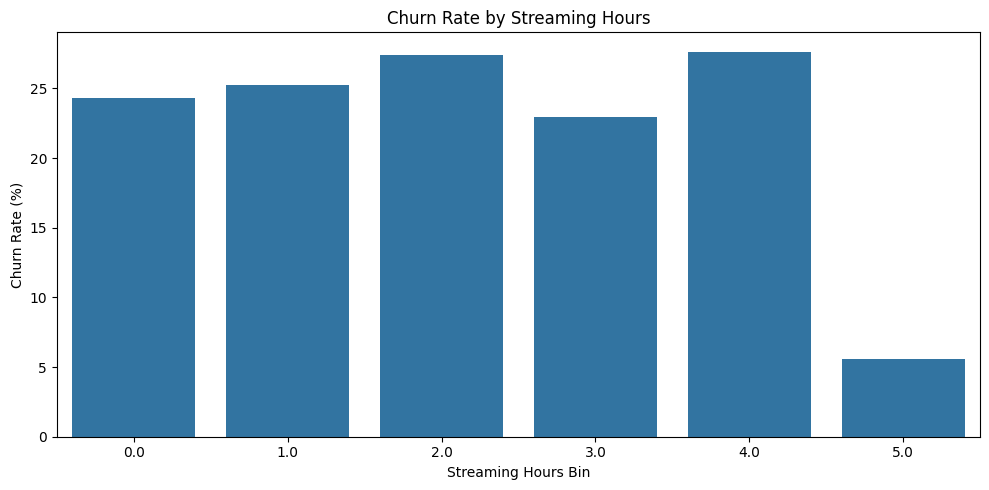

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=streaming_analysis,
    x="streaming_bin",
    y=streaming_analysis["churn_rate"] * 100
)

plt.xlabel("Streaming Hours Bin")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Streaming Hours")
plt.tight_layout()
plt.show()

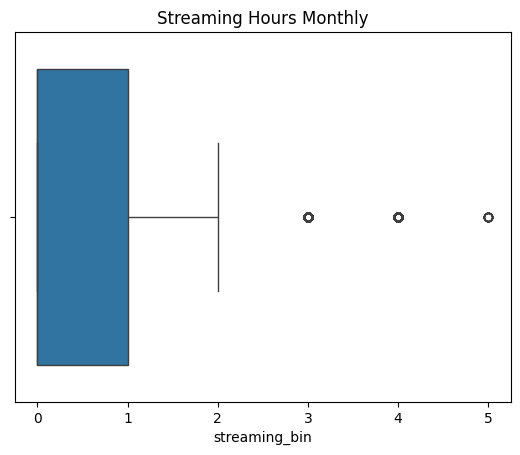

In [46]:
sns.boxplot(
    data=train,
    x="streaming_bin"
)

plt.title("Streaming Hours Monthly")
plt.show()

### device_age_months

In [47]:
train['device_age_months']

0        55.0
1         3.0
2        10.0
3         2.0
4         9.0
         ... 
11995     3.0
11996     9.0
11997     4.0
11998     9.0
11999    24.0
Name: device_age_months, Length: 12000, dtype: float64

In [48]:
train['device_age_months'].describe()

count    11664.000000
mean        14.401406
std         17.661620
min          0.000000
25%          3.000000
50%          8.000000
75%         19.000000
max         96.000000
Name: device_age_months, dtype: float64

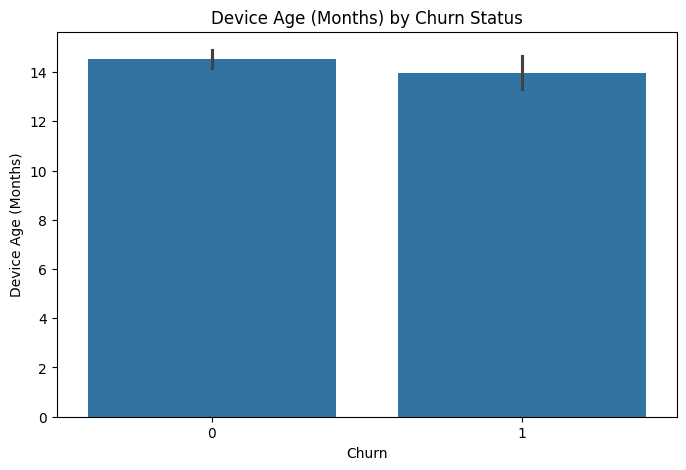

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='churn', y='device_age_months')
plt.title('Device Age (Months) by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Device Age (Months)')
plt.show()

In [50]:
train['device_age_months'].value_counts(bins=10).sort_index()

(-0.097, 9.6]    6361
(9.6, 19.2]      2415
(19.2, 28.8]     1134
(28.8, 38.4]      713
(38.4, 48.0]      383
(48.0, 57.6]      226
(57.6, 67.2]      150
(67.2, 76.8]       77
(76.8, 86.4]       58
(86.4, 96.0]      147
Name: count, dtype: int64

In [51]:
train['device_tier'] = pd.cut(
    train['device_age_months'], 
    bins=[-np.inf, 12, 24, np.inf], 
    labels=['< 1 Year', '1-2 Years', '2+ Years']
)
train['device_tier'].value_counts()

device_tier
< 1 Year     7248
1-2 Years    2256
2+ Years     2160
Name: count, dtype: int64

In [52]:
device_tier_analysis = (
    train
    .groupby("device_tier", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(device_tier_analysis)

  device_tier  customers  churned  churn_rate
0    < 1 Year       7248     1896    0.261589
1   1-2 Years       2256      469    0.207890
2    2+ Years       2160      525    0.243056


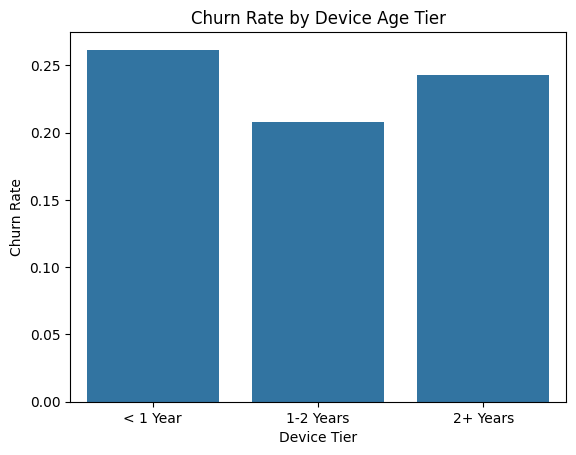

In [53]:
sns.barplot(
    data=device_tier_analysis,
    x="device_tier",
    y="churn_rate"
)

plt.xlabel("Device Tier")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Device Age Tier")
plt.show()

In [54]:
device_analysis = (
    train
    .groupby("churn")
    .agg(
        customers=("device_age_months", "size"),
        mean_device_age=("device_age_months", "mean"),
        median_device_age=("device_age_months", "median"),
        std_device_age=("device_age_months", "std")
    )
    .reset_index()
)

print(device_analysis)

   churn  customers  mean_device_age  median_device_age  std_device_age
0      0       9037        14.550832                9.0       17.264601
1      1       2963        13.947751                7.0       18.811568


In [55]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="device_age_months",
    target="churn",
    max_bins=6
)

print("Thresholds:", thresholds)

Thresholds: [np.float64(2.5), np.float64(3.5), np.float64(8.5), np.float64(31.5), np.float64(39.5)]


In [56]:
bins = [-np.inf] + thresholds + [np.inf]

train["device_age_bin"] = pd.cut(
    train["device_age_months"],
    bins=bins,
    labels=False,
    include_lowest=True
)

In [57]:
device_bin_analysis = (
    train
    .groupby("device_age_bin", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(device_bin_analysis)

   device_age_bin  customers  churned  churn_rate
0             0.0       2845      883    0.310369
1             1.0        734      202    0.275204
2             2.0       2404      555    0.230865
3             3.0       4194      860    0.205055
4             4.0        493      109    0.221095
5             5.0        994      281    0.282696


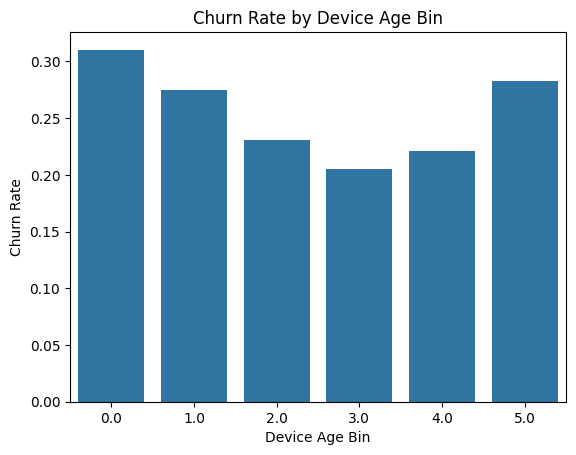

In [58]:
sns.barplot(
    data=device_bin_analysis,
    x="device_age_bin",
    y="churn_rate"
)

plt.xlabel("Device Age Bin")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Device Age Bin")
plt.show()

In [59]:
columns = ["streaming_bin","data_usage_bin","device_age_bin"]

In [60]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   customer_id              12000 non-null  object  
 1   age                      11628 non-null  float64 
 2   tenure_months            11520 non-null  float64 
 3   number_of_services       11584 non-null  float64 
 4   data_usage_gb            11493 non-null  float64 
 5   streaming_hours_monthly  11192 non-null  float64 
 6   device_age_months        11664 non-null  float64 
 7   app_sessions_weekly      11498 non-null  float64 
 8   average_session_minutes  11425 non-null  float64 
 9   payment_delay_days       11346 non-null  float64 
 10  late_payment_count       11420 non-null  float64 
 11  discount_percentage      11374 non-null  float64 
 12  monthly_charge           11548 non-null  float64 
 13  network_complaints       11373 non-null  float64 
 14  suppor

### app_sessions_weekly

In [61]:
train['app_sessions_weekly'].count()

np.int64(11498)

In [62]:
train['app_sessions_weekly'].describe()

count    11498.000000
mean        12.094103
std          6.111103
min          0.000000
25%          8.000000
50%         12.000000
75%         16.000000
max         39.000000
Name: app_sessions_weekly, dtype: float64

In [63]:
train['app_sessions_weekly'].value_counts(bins=3).sort_index()

(-0.04, 13.0]    6947
(13.0, 26.0]     4385
(26.0, 39.0]      166
Name: count, dtype: int64

In [64]:
train['app_engagement'] = pd.cut(
    train['app_sessions_weekly'], 
    bins=[-1, 2, 7, 20, 1000], 
    labels=['Inactive (0-2)', 'Low (3-7)', 'Moderate (8-20)', 'High (21+)']
)
train['app_engagement'].value_counts()

app_engagement
Moderate (8-20)    7834
Low (3-7)          1997
High (21+)         1014
Inactive (0-2)      653
Name: count, dtype: int64

In [65]:
train['app_engagement'] = pd.cut(
    train['app_sessions_weekly'],
    bins=[0, 3, 7, 14, 21, np.inf],
    labels=['Inactive', 'Low', 'Medium', 'High', 'VeryHigh']
)
train['app_engagement'].value_counts()

app_engagement
Medium      4975
High        3091
Low         1723
VeryHigh     782
Inactive     681
Name: count, dtype: int64

In [66]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="app_sessions_weekly",
    target="churn",
    max_bins=6
)

print("Thresholds:", thresholds)

Thresholds: [np.float64(2.5), np.float64(11.5), np.float64(13.5), np.float64(18.5), np.float64(21.5)]


In [67]:
bins = [-np.inf] + thresholds + [np.inf]

train["app_engagement"] = pd.cut(
    train["app_sessions_weekly"],
    bins=bins,
    labels=False,
    include_lowest=True
)

In [133]:
app_engagement_bin_analysis = (
    train
    .groupby("app_engagement", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(app_engagement_bin_analysis)

   app_engagement  customers  churned  churn_rate
0             0.0        653      197    0.301685
1             1.0       4816     1180    0.245017
2             2.0       1478      333    0.225304
3             3.0       2876      694    0.241307
4             4.0        893      227    0.254199
5             5.0        782      215    0.274936


In [134]:
train['app_engagement'].value_counts()

app_engagement
1.0    4816
3.0    2876
2.0    1478
4.0     893
5.0     782
0.0     653
Name: count, dtype: int64

In [70]:
columns = ["streaming_bin","data_usage_bin","device_age_bin","app_engagement"]


In [71]:
train['danger_zone'] = (
    (train['app_sessions_weekly'] < 5) & 
    (train['satisfaction_score'] < 5)
).astype(int)


In [72]:
danger_analysis = (
    train
    .groupby("danger_zone")
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(danger_analysis)

   danger_zone  customers  churned  churn_rate
0            0      11993     2957    0.246560
1            1          7        6    0.857143


### average_session_minutes

In [73]:
train['average_session_minutes'].value_counts()

average_session_minutes
5.5     109
4.5     102
5.2     102
4.9     101
5.0     100
       ... 
46.5      1
53.9      1
48.6      1
45.3      1
41.6      1
Name: count, Length: 475, dtype: int64

In [74]:
train['average_session_minutes'].describe()

count    11425.000000
mean        11.317952
std          8.271135
min          0.600000
25%          5.800000
50%          9.200000
75%         14.300000
max        135.400000
Name: average_session_minutes, dtype: float64

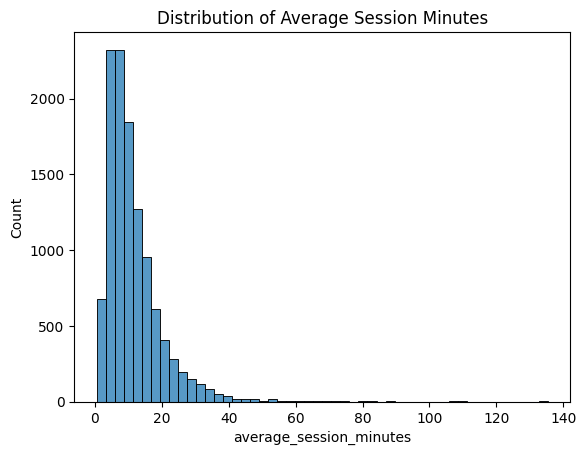

In [75]:
sns.histplot(
    data=train,
    x="average_session_minutes",
    bins=50
)

plt.title("Distribution of Average Session Minutes")
plt.show()

In [76]:
session_analysis = (
    train
    .groupby("churn")
    .agg(
        customers=("churn", "size"),
        mean_session=("average_session_minutes", "mean"),
        median_session=("average_session_minutes", "median")
    )
    .reset_index()
)

print(session_analysis)

   churn  customers  mean_session  median_session
0      0       9037     11.401500             9.2
1      1       2963     11.063492             9.0


In [77]:
train["average_session_log"] = np.log1p(
    train["average_session_minutes"]
)

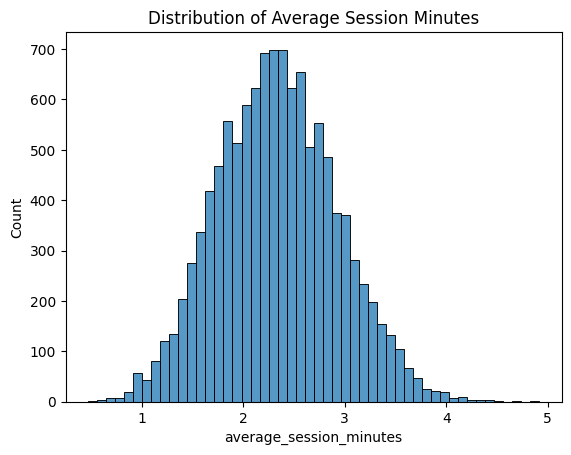

In [78]:
np.log1p(
    train["average_session_minutes"]
)

sns.histplot(
    data=train,
    x=np.log1p(
    train["average_session_minutes"]
),
    bins=50
)

plt.title("Distribution of Average Session Minutes")
plt.show()

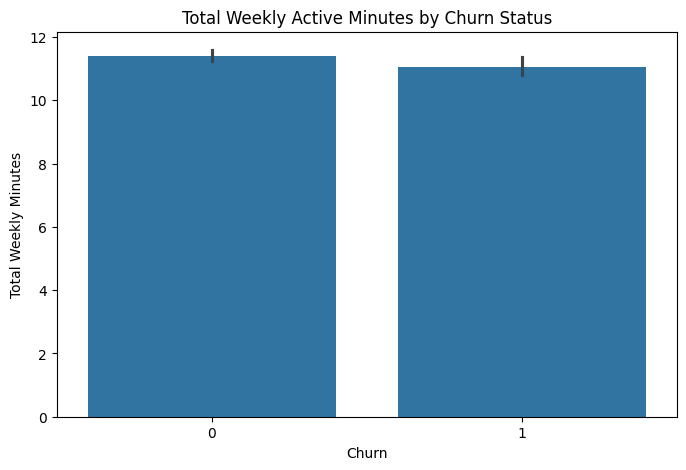

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='churn', y='average_session_minutes')
# sns.boxplot(data=train, x='churn', y='average_session_minutes')
plt.title('Total Weekly Active Minutes by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Weekly Minutes')
plt.show()

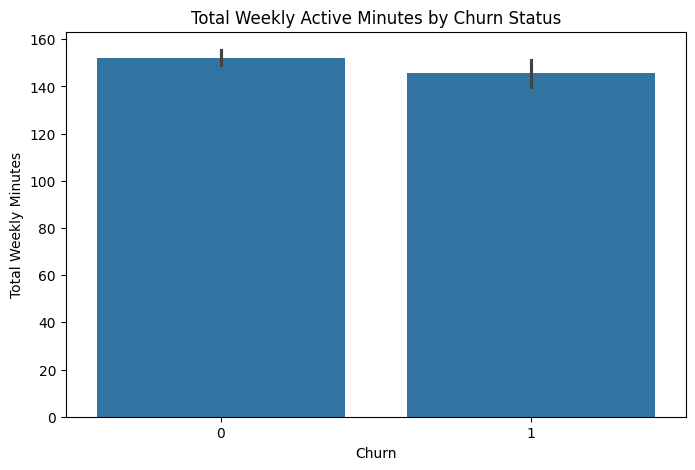

In [80]:
# Create total estimated minutes spent per week
train['total_weekly_minutes'] = train['app_sessions_weekly'] * train['average_session_minutes']

plt.figure(figsize=(8, 5))
# sns.boxplot(data=train, x='churn', y='total_weekly_minutes')
sns.barplot(data=train, x='churn', y='total_weekly_minutes')

plt.title('Total Weekly Active Minutes by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Weekly Minutes')
plt.show()

In [81]:
usage_analysis = (
    train
    .groupby("churn")
    .agg(
        customers=("churn", "size"),
        mean_weekly_minutes=("total_weekly_minutes", "mean"),
        median_weekly_minutes=("total_weekly_minutes", "median")
    )
    .reset_index()
)

print(usage_analysis)

   churn  customers  mean_weekly_minutes  median_weekly_minutes
0      0       9037           152.271796                  108.0
1      1       2963           145.808263                  104.0


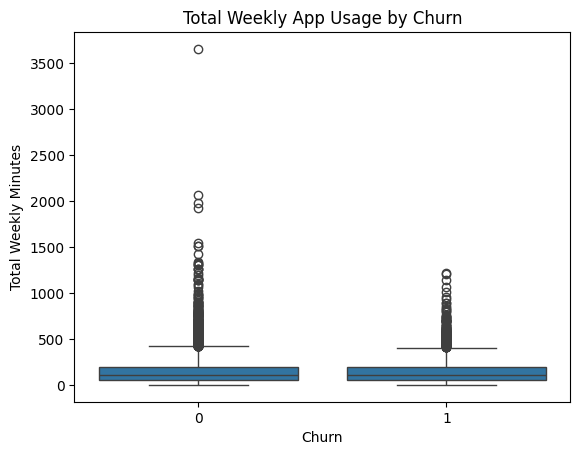

In [82]:
sns.boxplot(
    data=train,
    x="churn",
    y="total_weekly_minutes"
)

plt.title("Total Weekly App Usage by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Weekly Minutes")
plt.show()

### payment_delay_days

In [83]:
train['payment_delay_days'].value_counts()

payment_delay_days
0.0     9772
1.0      566
2.0      293
3.0      181
4.0      135
5.0       87
6.0       76
7.0       45
8.0       42
9.0       30
10.0      24
12.0      13
11.0      11
15.0       9
14.0       8
13.0       5
19.0       4
36.0       3
35.0       3
27.0       3
22.0       3
39.0       3
34.0       3
16.0       3
18.0       3
43.0       2
29.0       2
31.0       2
24.0       2
21.0       2
17.0       2
40.0       1
42.0       1
20.0       1
45.0       1
46.0       1
26.0       1
44.0       1
41.0       1
28.0       1
Name: count, dtype: int64

In [84]:
train['payment_delay_days'].describe()

count    11346.000000
mean         0.554821
std          2.477264
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         46.000000
Name: payment_delay_days, dtype: float64

In [85]:
thresholds = learn_optimal_bins(
    train_df=train,
    column="payment_delay_days",
    target="churn",
    max_bins=6
)

print("Thresholds:", thresholds)

Thresholds: [np.float64(0.5), np.float64(2.5), np.float64(inf)]


In [86]:
# 1. Create a binary flag: Has the customer ever been delayed?
train['has_payment_delay'] = (train['payment_delay_days'] > 0).astype(int)

bins = [-np.inf] + thresholds

train['payment_delay_tier'] = pd.cut(
    train['payment_delay_days'],
    bins=bins,
)

# # 3. Check churn rate across these delay tiers
churn_by_delay = train.groupby('payment_delay_tier')['churn'].mean() * 100
print(churn_by_delay)

payment_delay_tier
(-inf, 0.5]    23.065903
(0.5, 2.5]     27.473807
(2.5, inf]     41.958042
Name: churn, dtype: float64


In [87]:
pay_bin_analysis = (
    train
    .groupby("payment_delay_tier", observed=True)
    .agg(
        customers=("churn", "size"),
        churned=("churn", "sum"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
)

print(pay_bin_analysis)

  payment_delay_tier  customers  churned  churn_rate
0        (-inf, 0.5]       9772     2254    0.230659
1         (0.5, 2.5]        859      236    0.274738
2         (2.5, inf]        715      300    0.419580


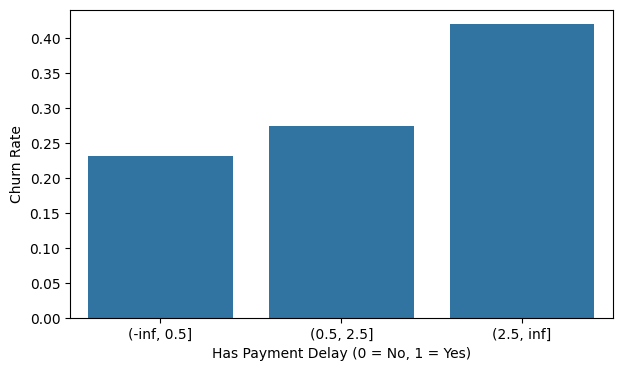

In [88]:

plt.figure(figsize=(7, 4))
sns.barplot(data=train, x='payment_delay_tier', y='churn', ci=None)
plt.xlabel('Has Payment Delay (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.show()

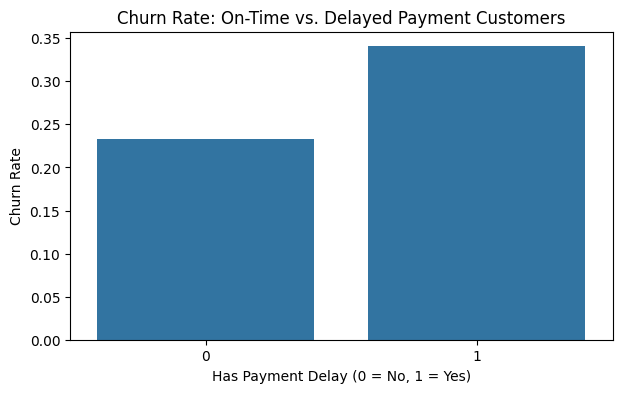

In [89]:

plt.figure(figsize=(7, 4))
sns.barplot(data=train, x='has_payment_delay', y='churn', ci=None)
plt.title('Churn Rate: On-Time vs. Delayed Payment Customers')
plt.xlabel('Has Payment Delay (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.show()

### late_payment_count

In [90]:
train['late_payment_count'].value_counts()

late_payment_count
0.0    7964
1.0    2574
2.0     590
3.0     177
4.0      72
5.0      24
6.0      10
8.0       4
9.0       3
7.0       2
Name: count, dtype: int64

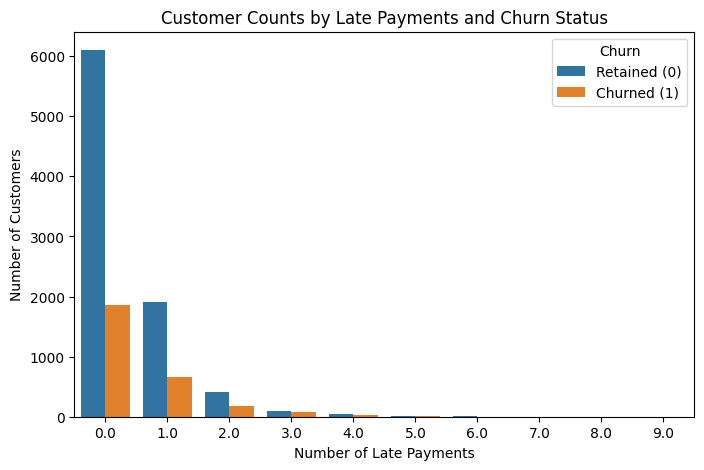

In [91]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='late_payment_count', hue='churn')
plt.title('Customer Counts by Late Payments and Churn Status')
plt.xlabel('Number of Late Payments')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Retained (0)', 'Churned (1)'])
plt.show()

In [92]:
import pandas as pd
# Use capital 'Int64' (or 'Int32', 'Int16') instead of 'int' or np.int64
train['late_payment_count'] = train['late_payment_count'].astype('Int64')
# Fill NaNs with 0, then safely convert to standard int
train['late_payment_count'] = train['late_payment_count'].fillna(0).astype(int)
# Group values 3 and above into '3+'
train['late_payment_group'] = train['late_payment_count'].apply(
    lambda x: '3+' if x >= 3 else str(int(x))
)

In [93]:
train['late_payment_group'].value_counts()

late_payment_group
0     8544
1     2574
2      590
3+     292
Name: count, dtype: int64

In [94]:
train.groupby('late_payment_group')['churn'].mean()

late_payment_group
0     0.232912
1     0.259907
2     0.296610
3+    0.441781
Name: churn, dtype: float64

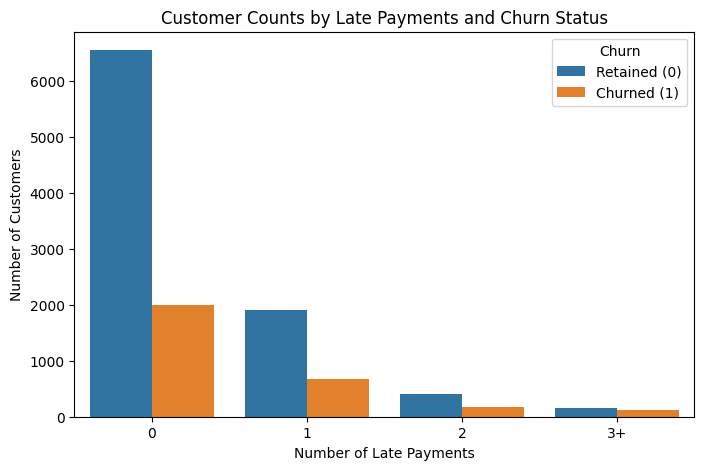

In [95]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='late_payment_group', hue='churn')
plt.title('Customer Counts by Late Payments and Churn Status')
plt.xlabel('Number of Late Payments')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Retained (0)', 'Churned (1)'])
plt.show()

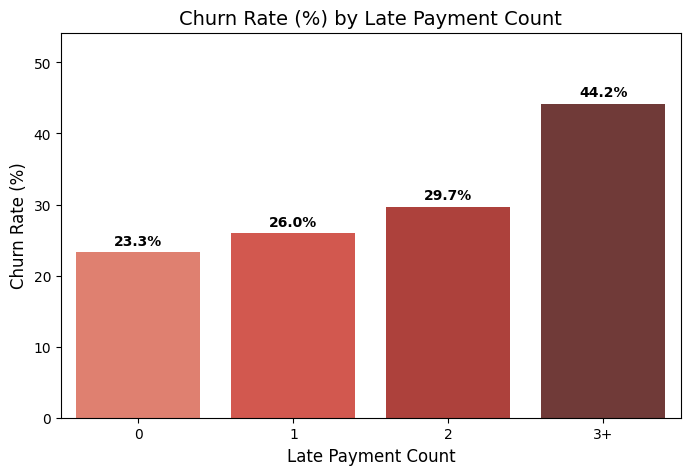

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate churn percentage per group
churn_rates = train.groupby('late_payment_group')['churn'].mean().reindex(['0', '1', '2', '3+']) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_rates.index, y=churn_rates.values, palette='Reds_d')
plt.title('Churn Rate (%) by Late Payment Count', fontsize=14)
plt.xlabel('Late Payment Count', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

# Annotate values above each bar
for i, rate in enumerate(churn_rates):
    plt.text(i, rate + 1, f"{rate:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, max(churn_rates) + 10)
plt.show()

### discount_percentage

In [97]:
train['discount_percentage'].describe()

count    11374.000000
mean         7.486109
std          8.261282
min          0.000000
25%          0.000000
50%          4.000000
75%         12.000000
max         38.000000
Name: discount_percentage, dtype: float64

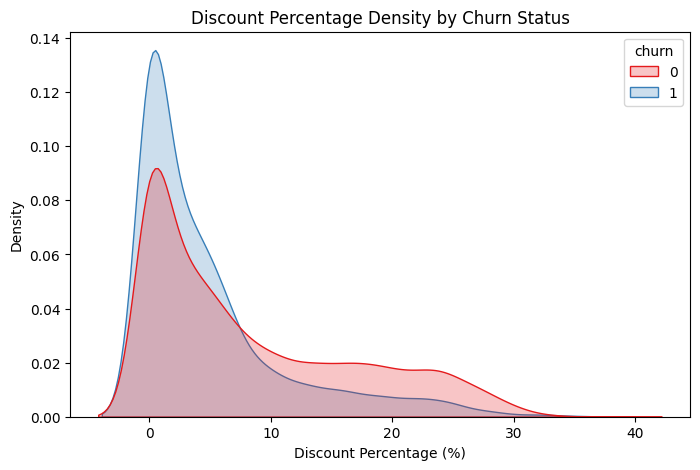

In [98]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=train, 
    x='discount_percentage', 
    hue='churn', 
    common_norm=False, 
    fill=True, 
    palette='Set1'
)
plt.title('Discount Percentage Density by Churn Status')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Density')
plt.show()

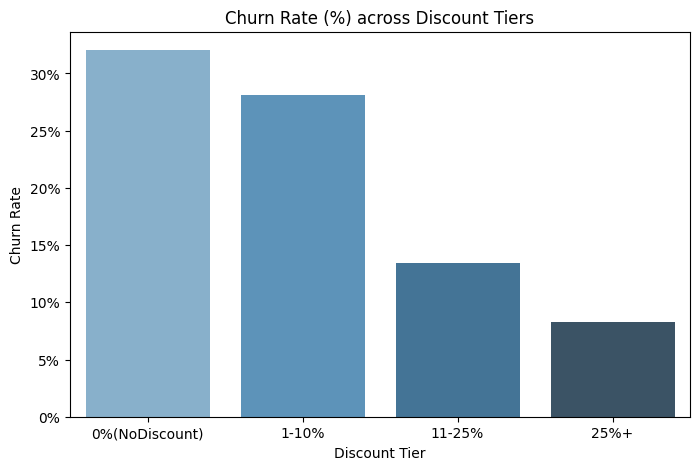

In [99]:
# If continuous, group into 4 discount tiers first:
train['discount_tier'] = pd.cut(
    train['discount_percentage'], 
    bins=[-1, 0, 10, 25, 100], 
    labels=['0%(NoDiscount)', '1-10%', '11-25%', '25%+']
)

# Plot Churn Rate (%) per tier
plt.figure(figsize=(8, 5))
sns.barplot(
    data=train, 
    x='discount_tier', 
    y='churn', 
    palette='Blues_d', 
    ci=None
)
plt.title('Churn Rate (%) across Discount Tiers')
plt.xlabel('Discount Tier')
plt.ylabel('Churn Rate')
plt.gca().yaxis.set_major_formatter('{x:.0%}')  # Formats Y-axis as percentage
plt.show()

In [100]:
train['discount_tier']

0                11-25%
1        0%(NoDiscount)
2        0%(NoDiscount)
3                 1-10%
4                 1-10%
              ...      
11995             1-10%
11996             1-10%
11997            11-25%
11998             1-10%
11999             1-10%
Name: discount_tier, Length: 12000, dtype: category
Categories (4, object): ['0%(NoDiscount)' < '1-10%' < '11-25%' < '25%+']

In [101]:
train.groupby(by = "discount_tier")["churn"].mean()

discount_tier
0%(NoDiscount)    0.320438
1-10%             0.281070
11-25%            0.134355
25%+              0.082405
Name: churn, dtype: float64

### monthly_charge

In [102]:
train['monthly_charge']


0        51.75
1        63.88
2        89.40
3        52.92
4        46.53
         ...  
11995    49.38
11996    69.37
11997    24.35
11998    54.30
11999    48.80
Name: monthly_charge, Length: 12000, dtype: float64

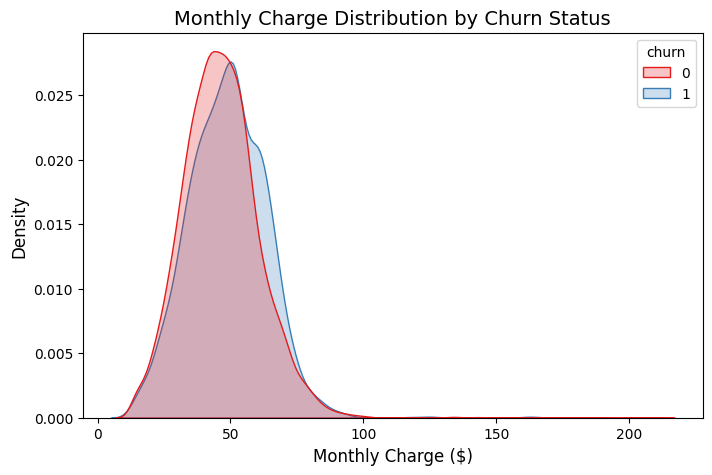

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=train, 
    x='monthly_charge', 
    hue='churn', 
    common_norm=False, 
    fill=True, 
    palette='Set1'
)
plt.title('Monthly Charge Distribution by Churn Status', fontsize=14)
plt.xlabel('Monthly Charge ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

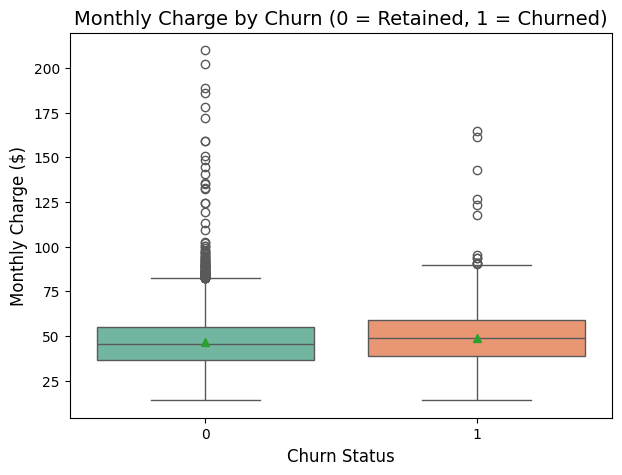

In [104]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=train, 
    x='churn', 
    y='monthly_charge', 
    palette='Set2',
    showmeans=True
)
plt.title('Monthly Charge by Churn (0 = Retained, 1 = Churned)', fontsize=14)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charge ($)', fontsize=12)
plt.show()

In [137]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               12000 non-null  object  
 1   age                       11628 non-null  float64 
 2   tenure_months             11520 non-null  float64 
 3   number_of_services        11584 non-null  float64 
 4   data_usage_gb             11493 non-null  float64 
 5   streaming_hours_monthly   11192 non-null  float64 
 6   device_age_months         11664 non-null  float64 
 7   app_sessions_weekly       11498 non-null  float64 
 8   average_session_minutes   11425 non-null  float64 
 9   payment_delay_days        11346 non-null  float64 
 10  late_payment_count        12000 non-null  int64   
 11  discount_percentage       11374 non-null  float64 
 12  monthly_charge            11548 non-null  float64 
 13  network_complaints        11373 non-null  floa

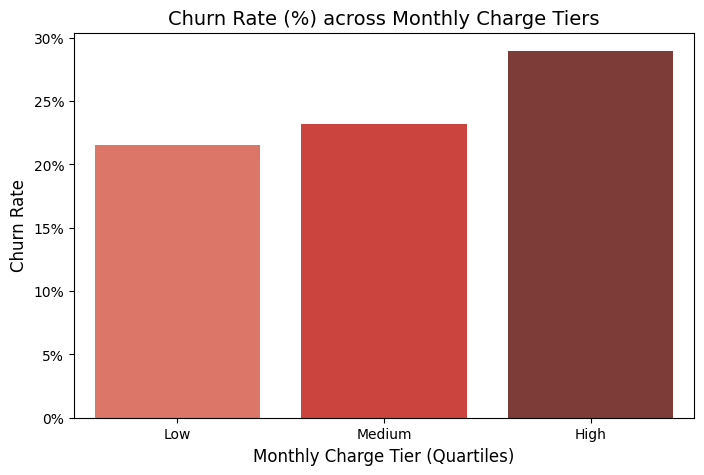

In [105]:
import pandas as pd

# 1. Create price tiers (e.g., Low, Medium, High, Premium)
train['charge_tier'] = pd.qcut(train['monthly_charge'], q=3, labels=['Low', 'Medium', 'High',])

# 2. Plot Churn Rate (%) per tier
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='charge_tier', y='churn', palette='Reds_d', ci=None)
plt.title('Churn Rate (%) across Monthly Charge Tiers', fontsize=14)
plt.xlabel('Monthly Charge Tier (Quartiles)', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.gca().yaxis.set_major_formatter('{x:.0%}')
plt.show()

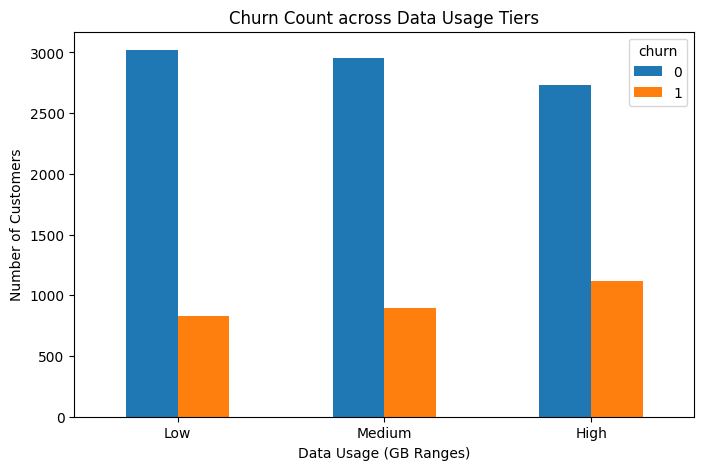

In [106]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
charge_tier_bin = pd.crosstab(train['charge_tier'], train['churn'])

# 3. Plot a side-by-side bar chart
charge_tier_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [107]:
# # 1. Create a binned column with 3 equal intervals

# # 2. Create a crosstab between usage bins and churn
# charge_tier_bin = pd.crosstab(train['monthly_charge'], train['churn'])

# # 3. Plot a side-by-side bar chart
# charge_tier_bin.plot(kind='bar', figsize=(8, 5))
# plt.title('Churn Count across Data Usage Tiers')
# plt.xlabel('Data Usage (GB Ranges)')
# plt.ylabel('Number of Customers')
# plt.xticks(rotation=0)
# plt.show()

In [108]:
train['network_complaints'].value_counts()

network_complaints
0.0    8360
1.0    1864
2.0     774
3.0     279
4.0      71
5.0      17
6.0       4
7.0       3
8.0       1
Name: count, dtype: int64

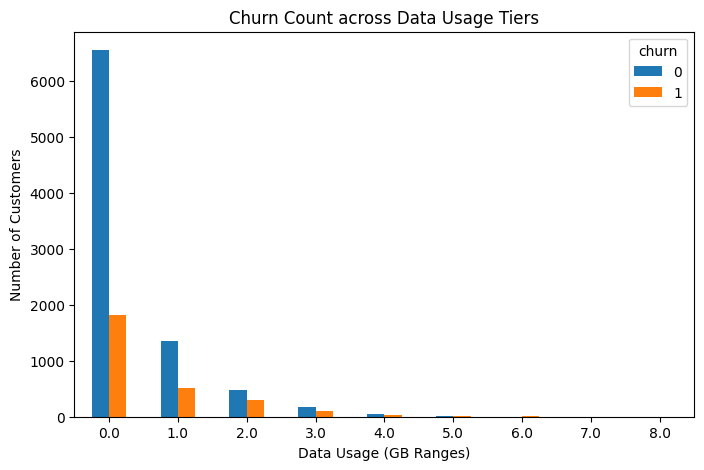

In [109]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
network_complaints_bin = pd.crosstab(train['network_complaints'], train['churn'])

# 3. Plot a side-by-side bar chart
network_complaints_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### support_calls_90d

In [110]:
train['support_calls_90d'].value_counts()

support_calls_90d
1.0     3492
0.0     3168
2.0     2453
3.0     1298
4.0      549
5.0      224
6.0       74
7.0       31
8.0       11
27.0       4
25.0       4
26.0       3
22.0       3
31.0       3
33.0       2
9.0        2
23.0       2
34.0       2
37.0       2
36.0       2
30.0       2
28.0       2
20.0       2
10.0       1
14.0       1
16.0       1
24.0       1
29.0       1
18.0       1
32.0       1
39.0       1
15.0       1
17.0       1
19.0       1
21.0       1
Name: count, dtype: int64

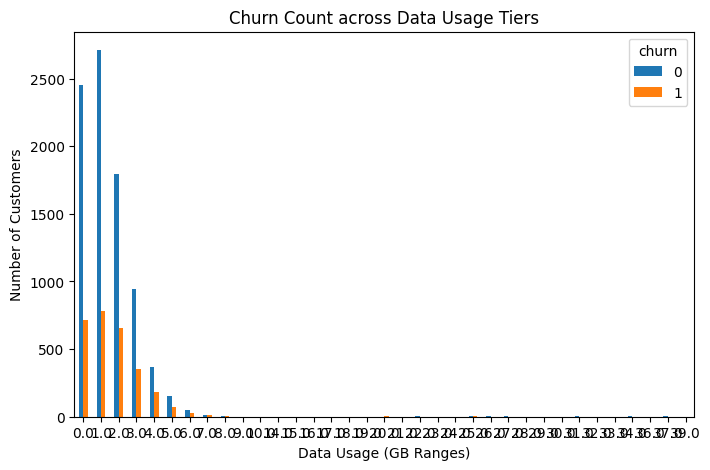

In [111]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
support_calls_90d_bin = pd.crosstab(train['support_calls_90d'], train['churn'])

# 3. Plot a side-by-side bar chart
support_calls_90d_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

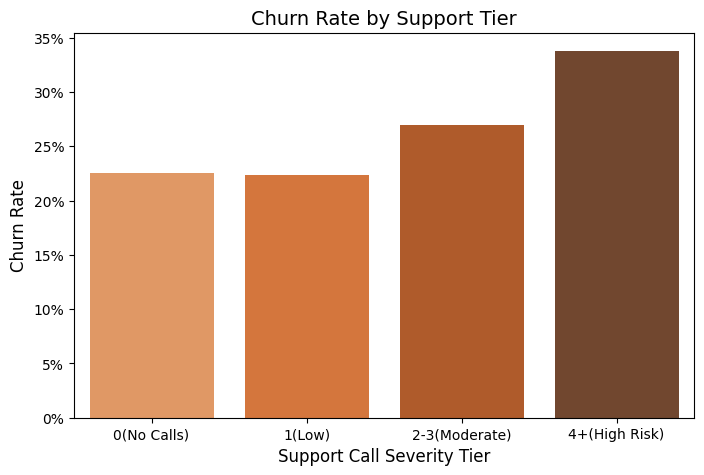

In [112]:
# Define support call tiers
train['support_tier'] = pd.cut(
    train['support_calls_90d'],
    bins=[-1, 0, 1, 3, 100],
    labels=['0(No Calls)', '1(Low)', '2-3(Moderate)', '4+(High Risk)']
)

# Plot Churn Rate by Tier
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='support_tier', y='churn', palette='Oranges_d', ci=None)
plt.title('Churn Rate by Support Tier', fontsize=14)
plt.xlabel('Support Call Severity Tier', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.gca().yaxis.set_major_formatter('{x:.0%}')
plt.show()

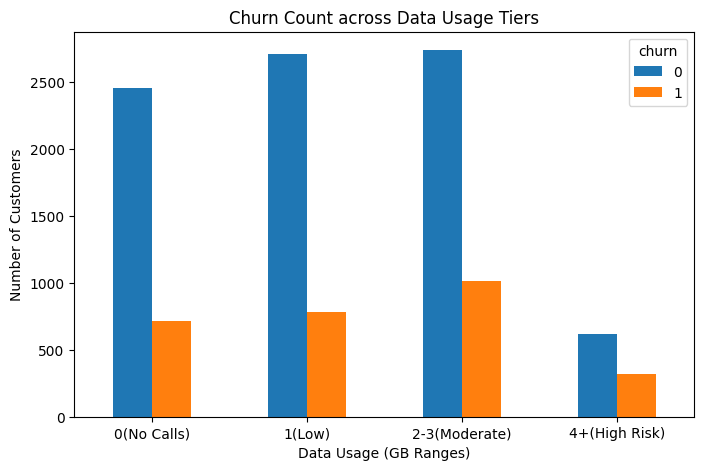

In [113]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
support_calls_90d_bin = pd.crosstab(train['support_tier'], train['churn'])

# 3. Plot a side-by-side bar chart
support_calls_90d_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [114]:
train['high_support_risk'] = (train['support_calls_90d'] >= 3).astype(int)

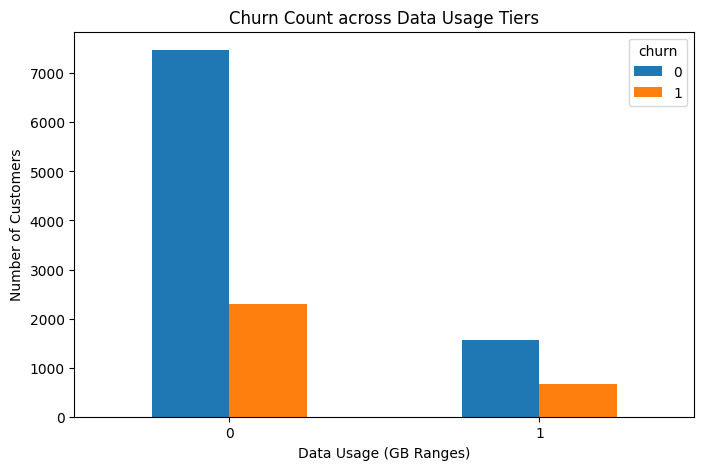

In [115]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
support_calls_90d_bin = pd.crosstab(train['high_support_risk'], train['churn'])

# 3. Plot a side-by-side bar chart
support_calls_90d_bin.plot(kind='bar', figsize=(8, 5))
plt.title('Churn Count across Data Usage Tiers')
plt.xlabel('Data Usage (GB Ranges)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### satisfaction_score

In [116]:
train['satisfaction_score']

0         9.1
1         6.4
2         NaN
3         7.7
4         8.5
         ... 
11995     9.1
11996     6.9
11997    10.0
11998     7.9
11999     8.3
Name: satisfaction_score, Length: 12000, dtype: float64

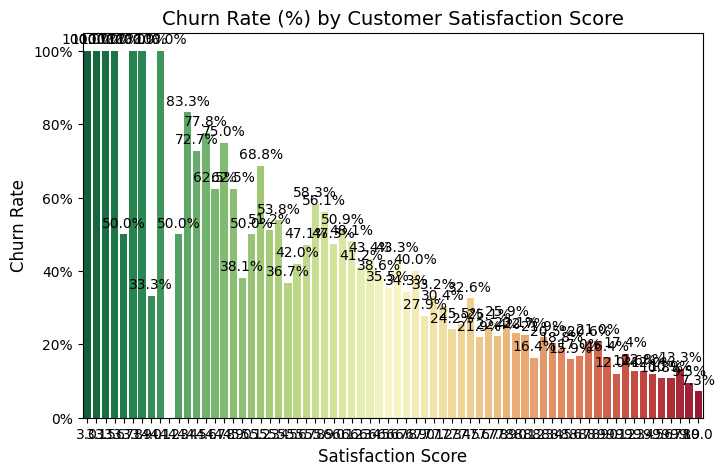

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=train, 
    x='satisfaction_score', 
    y='churn', 
    palette='RdYlGn_r',  # Red for low scores, green for high scores
    ci=None
)
plt.title('Churn Rate (%) by Customer Satisfaction Score', fontsize=14)
plt.xlabel('Satisfaction Score', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.gca().yaxis.set_major_formatter('{x:.0%}')

# Add percentage annotations on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                    textcoords='offset points')

plt.show()

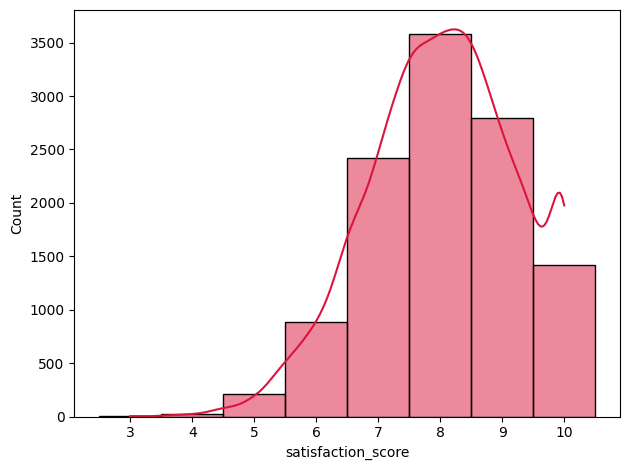

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot 1: Histogram showing the right skew (distribution shape)
sns.histplot(data=train, x='satisfaction_score', kde=True, color='crimson', discrete=True)



plt.tight_layout()
plt.show()

### referral_count

In [119]:
train['referral_count'].value_counts()

referral_count
0.0    8460
1.0    1736
2.0     827
3.0     264
4.0     103
5.0      29
6.0       6
7.0       1
Name: count, dtype: int64

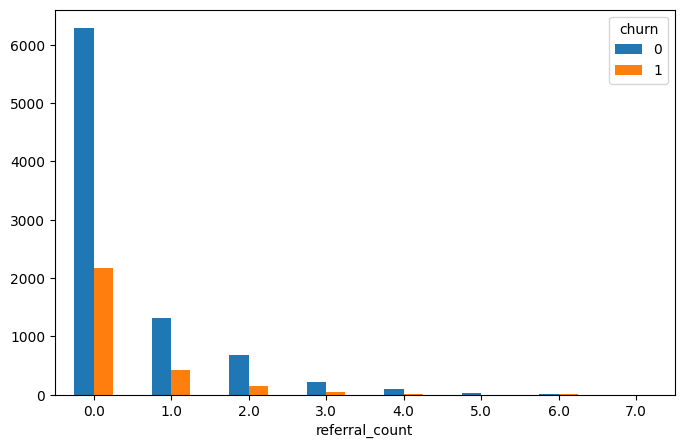

In [120]:
# 1. Create a binned column with 3 equal intervals

# 2. Create a crosstab between usage bins and churn
referral_count_bin = pd.crosstab(train['referral_count'], train['churn'])

# 3. Plot a side-by-side bar chart
referral_count_bin.plot(kind='bar', figsize=(8, 5))

plt.xticks(rotation=0)
plt.show()

In [121]:
corr_value = train['referral_count'].corr(train['churn'])

print("Correlation between referral_count and churn:", corr_value)

Correlation between referral_count and churn: -0.060974582182629224


### lifetime_spend

In [122]:
train['lifetime_spend']

0        2283.57
1        1422.24
2         930.22
3         570.98
4        1555.89
          ...   
11995     507.61
11996     487.32
11997    1159.90
11998     937.93
11999      34.77
Name: lifetime_spend, Length: 12000, dtype: float64

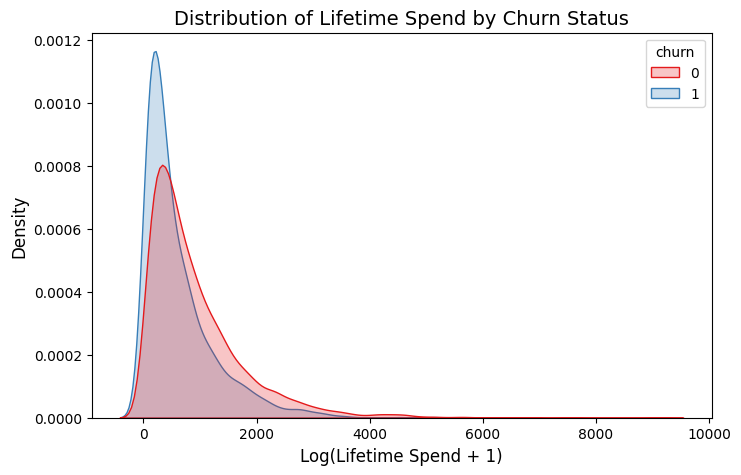

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=train, 
    # x=np.log1p(train['lifetime_spend']), 
    x = train['lifetime_spend'],
    hue='churn', 
    common_norm=False, 
    fill=True, 
    palette='Set1'
)
plt.title('Distribution of Lifetime Spend by Churn Status', fontsize=14)
plt.xlabel('Log(Lifetime Spend + 1)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

In [124]:
corr_value = train['lifetime_spend'].corr(train['churn'])

print("Correlation between lifetime_spend and churn:", corr_value)

Correlation between lifetime_spend and churn: -0.1562864629167186


In [125]:
train['calculated_tenure_months'] = train['lifetime_spend'] / (train['monthly_charge'] + 1e-5)

corr_value = train['calculated_tenure_months'].corr(train['churn'])

print("Correlation between calculated_tenure_months and churn:", corr_value)

Correlation between calculated_tenure_months and churn: -0.18199921130439153


### categorical

In [126]:
cat_cols = [
    'customer_segment', 'region', 'acquisition_channel', 'contract_type',
    'plan_tier', 'internet_type', 'device_type', 'support_plan',
    'payment_method', 'promotion_type'
]
for col in cat_cols:
    print(f"--- Churn Rate by {col} ---")
    print(train.groupby(col)['churn'].agg(count='count', churn_rate='mean'))
    print("\n")

--- Churn Rate by customer_segment ---
                  count  churn_rate
customer_segment                   
Consumer           6828    0.232279
Enterprise          856    0.096963
Small Business     1305    0.153257
Student            2658    0.379985


--- Churn Rate by region ---
           count  churn_rate
region                      
Centralia   1656    0.283213
Eastvale    2795    0.234705
Northgate   3200    0.264062
Southport   1905    0.220997
Westhaven   2140    0.235047


--- Churn Rate by acquisition_channel ---
                     count  churn_rate
acquisition_channel                   
Outbound sales        4063    0.251046
Partner reseller       918    0.198257
Referral              1146    0.179756
Retail store          1393    0.256999
Website               4031    0.268668


--- Churn Rate by contract_type ---
                count  churn_rate
contract_type                    
Month-to-month   6728    0.360285
One year         2986    0.126591
Two year         199

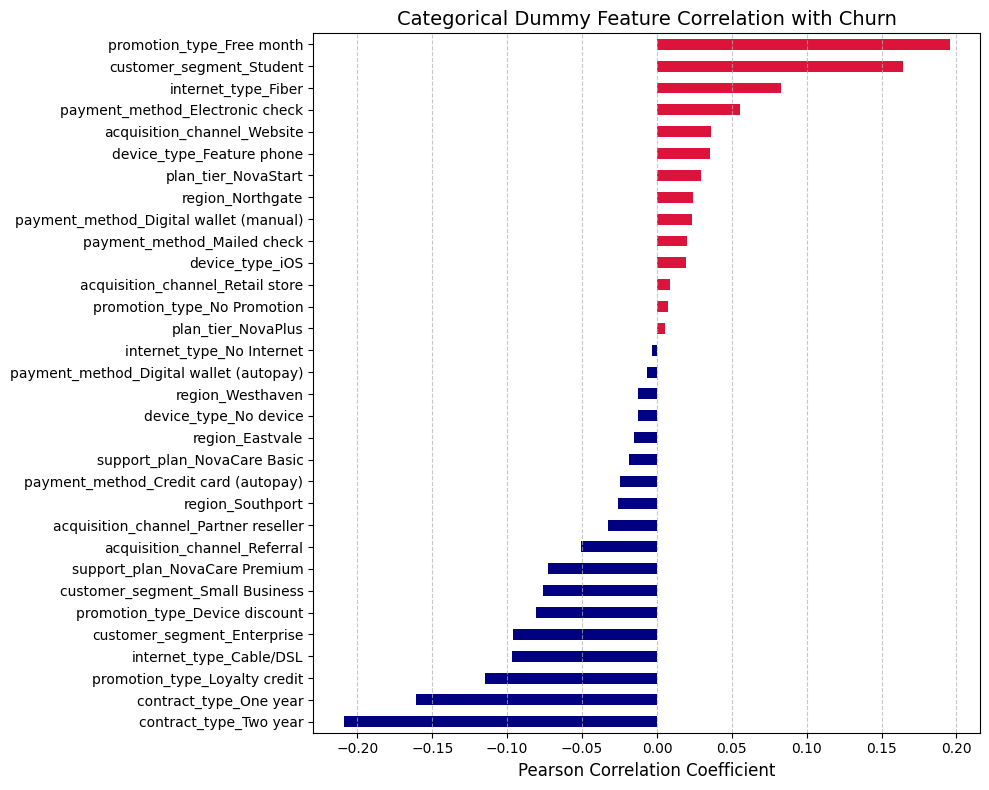

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute dummy correlations
corr_series = pd.get_dummies(train[cat_cols], drop_first=True).apply(lambda col: col.corr(train['churn'])).sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
corr_series.plot(kind='barh', color=corr_series.map(lambda x: 'crimson' if x > 0 else 'navy'))
plt.title('Categorical Dummy Feature Correlation with Churn', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [128]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / max(1, (kcorr-1)*(rcorr-1)))

# Calculate Cramér's V for every categorical column against churn
cramer_results = {}
for col in cat_cols:
    cramer_results[col] = cramers_v(train[col].fillna('Unknown'), train['churn'])

# Display sorted results
cramer_df = pd.DataFrame(list(cramer_results.items()), columns=['Feature', 'Cramers_V'])
print(cramer_df.sort_values(by='Cramers_V', ascending=False).to_string(index=False))

            Feature  Cramers_V
      contract_type   0.177433
     promotion_type   0.101770
   customer_segment   0.093807
      internet_type   0.051233
       support_plan   0.047962
     payment_method   0.032839
acquisition_channel   0.027694
          plan_tier   0.024377
        device_type   0.022803
             region   0.019663


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               12000 non-null  object  
 1   age                       11628 non-null  float64 
 2   tenure_months             11520 non-null  float64 
 3   number_of_services        11584 non-null  float64 
 4   data_usage_gb             11493 non-null  float64 
 5   streaming_hours_monthly   11192 non-null  float64 
 6   device_age_months         11664 non-null  float64 
 7   app_sessions_weekly       11498 non-null  float64 
 8   average_session_minutes   11425 non-null  float64 
 9   payment_delay_days        11346 non-null  float64 
 10  late_payment_count        12000 non-null  int64   
 11  discount_percentage       11374 non-null  float64 
 12  monthly_charge            11548 non-null  float64 
 13  network_complaints        11373 non-null  floa

In [130]:
train['international_plan'].value_counts()

international_plan
0.0    10083
1.0     1597
Name: count, dtype: int64

In [ ]:
train['la']

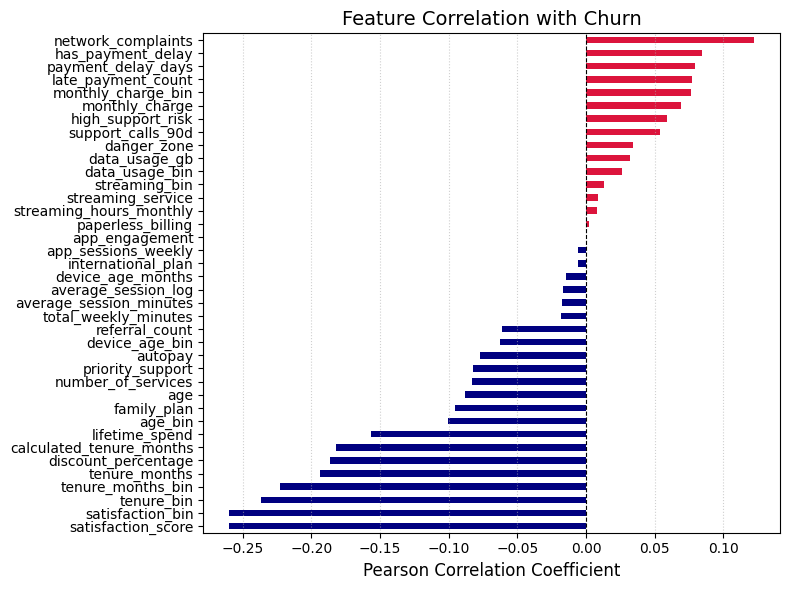

In [131]:
# 1. Compute correlations with the 'churn' column specifically
churn_corr = train.corr(numeric_only=True)['churn'].drop('churn').sort_values()

# 2. Plot as a horizontal bar chart
plt.figure(figsize=(8, 6))
churn_corr.plot(kind='barh', color=churn_corr.map(lambda x: 'crimson' if x > 0 else 'navy'))

plt.title('Feature Correlation with Churn', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [139]:
drop_cols = [
    'customer_id',

]

train = train.drop(columns=drop_cols)

In [142]:
# Correlation with target
correlations = train.corr(numeric_only=True)['churn']
print(correlations.head(20))  # Top 20 features

# Remove: |correlation| < 0.01 (likely noise)

age                       -0.087828
tenure_months             -0.193401
number_of_services        -0.082803
data_usage_gb              0.032378
streaming_hours_monthly    0.008073
device_age_months         -0.014742
app_sessions_weekly       -0.005831
average_session_minutes   -0.017629
payment_delay_days         0.079324
late_payment_count         0.076929
discount_percentage       -0.185999
monthly_charge             0.068917
network_complaints         0.122123
support_calls_90d          0.053760
satisfaction_score        -0.259551
referral_count            -0.060975
lifetime_spend            -0.156286
streaming_service          0.009048
priority_support          -0.082100
autopay                   -0.077477
Name: churn, dtype: float64
